In [1]:
# Run this setup only in Google Colab
import os
import subprocess
import sys
    
try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/ml2_trabalhos_2026")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", ".", "--no-deps"])
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount and install steps.")

Not running in Colab; skipping Drive mount and install steps.


# Trabalho 1 — Classificação de imagens com o Oxford-IIIT Pet

Neste trabalho, você irá treinar e comparar diferentes modelos para classificação de raças no dataset **Oxford-IIIT Pet**.

**Objetivos.**
- construir um pipeline básico de classificação de imagens;
- comparar arquiteturas simples e profundas;
- investigar o efeito de escolhas de treinamento;
- analisar erros e limitações do modelo.

**Entregáveis.**
1. Este notebook preenchido e executado.
2. Os pesos do melhor modelo;
2. Respostas curtas e objetivas nas células de texto.
3. Tabelas e gráficos pedidos ao longo do trabalho.

**Regras gerais.**
- Use **PyTorch**.
- Registre as escolhas principais de hiperparâmetros.
- Quando o enunciado pedir comparação, use evidências dos seus resultados.
- Não apague as células do enunciado.
- Use o conjunto de **teste** apenas na etapa final.



## Parte 0 — Setup e reprodutibilidade

Como treinamos algoritmos que possuem escolhas randômicas, e em máquinas com configurações possivelmente distintas. É importante tentar controlar essas variáveis para garantirmos o máximo de reprodutibilidade dos nossos experimentos.

**Tarefa 0.1**  
Fixe as seeds aleatórias e configure o dispositivo (`cpu` ou `cuda`).

**Tarefa 0.2**  
Imprima as versões de `torch` e `torchvision`, e indique se o notebook está usando CPU ou GPU.

**Tarefa 0.3**  
Crie uma variável `student_run_tag` com uma string curta de sua escolha (por exemplo, suas iniciais e a data).  
Use essa tag ao salvar modelos, figuras e demais artefatos produzidos no notebook.



In [90]:
# TODO: importe as bibliotecas principais
import random
import numpy as np
from pathlib import Path

import torch
import torchvision

# Sugestão: complete com torch.nn, torch.optim, matplotlib etc.
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import copy

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
# Adição de generator com a seed setada:
generator = torch.Generator().manual_seed(seed)

# torch.backend.cudnn.deterministic = True
# torch.backend.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Semente: {seed}")
print(f"Dispositivo: {device}")
print("Versão do Torch:", torch.__version__)
print("Versão do Torchvision:", torchvision.__version__)

student_run_tag = "tainaqd"
output_dir = Path("assignment1_outputs")
output_dir.mkdir(exist_ok=True)
(output_dir / student_run_tag).mkdir(exist_ok=True)
print("Diretório de saída:", output_dir / student_run_tag)

Semente: 42
Dispositivo: cuda
Versão do Torch: 2.11.0+cu126
Versão do Torchvision: 0.26.0+cu126
Diretório de saída: assignment1_outputs/tainaqd


## 1. Carregar dados e fazer split

Use o dataset **Oxford-IIIT Pet** do `torchvision`.

**Tarefas**
1. Baixe/carregue o dataset.
2. Separe os dados em **treino**, **validação** e **teste**.
3. Explique brevemente qual split você usou.
4. Mostre o número de exemplos em cada parte.

**Observação.**
- Você pode usar o split oficial de treino/teste e separar parte do treino para validação.
- Para a maior parte do trabalho, use inicialmente transformações simples.


In [3]:
# TODO:
# - importar OxfordIIITPet
# - definir transformações iniciais
# - carregar conjuntos
# - criar split treino/validação
# - criar DataLoaders

# Estrutura sugerida:
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

image_size = 224
batch_size = 64

# Escreva seu código aqui
transform = transforms.ToTensor()

In [4]:
# Download do dataset separado para treino/validação e teste
trainval_dataset = OxfordIIITPet(root="./data", split="trainval", transform=transform, download=True)
test_dataset = OxfordIIITPet(root="./data", split="test", transform=transform, download=True)

100%|██████████| 792M/792M [01:08<00:00, 11.6MB/s]  
100%|██████████| 19.2M/19.2M [00:03<00:00, 5.85MB/s]


In [5]:
# Separação de treino e validação
val_size = int(0.2 * len(trainval_dataset))
train_size = len(trainval_dataset) - val_size

train_dataset, val_dataset = random_split(trainval_dataset, [train_size, val_size], generator=generator)

In [6]:
# Criação dos DataLoaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### Resposta 1.3

Explique brevemente como você construiu o split de treino, validação e teste.


Inicialmente, utilizei o split padrão do dataset para separar em treino e teste. 
Depois, dividi o dataset de treino em 80% para treino e 20% para validação usando a função random_split. Para reprodutibilide dos resultados, utilizei o generator com a seed configurada no começo deste notebook.

Por fim, com cada um dos datasets devidamente separados, construí os DataLoaders com o batch_size=64.

## 2. Visualizar dados e inspecionar balanceamento

Antes de treinar, inspecione o dataset.

**Tarefas**
1. Mostre algumas imagens com seus rótulos.
2. Conte quantos exemplos há por classe no conjunto de treino.
3. Faça um gráfico simples da distribuição por classe.
4. Comente se o conjunto parece balanceado ou não.
5. Aponte ao menos uma dificuldade visual do problema.

In [7]:
# TODO:
# - mostrar algumas imagens do treino
# - obter nomes/classes
# - contar frequência por classe
# - fazer um gráfico simples

# Escreva seu código aqui
# Análise do formato dos dados
breed_names = train_dataset.dataset.classes
print(f"Número de classes: {len(breed_names)}")

print("Dez primeiros dados de treino:")
print(f"img format | breed id | breed name")
for i in range(10):
    image, label = train_dataset[i]
    print(image.shape, label, breed_names[label])


Número de classes: 37
Dez primeiros dados de treino:
img format | breed id | breed name
torch.Size([3, 375, 500]) 19 Leonberger
torch.Size([3, 352, 400]) 0 Abyssinian
torch.Size([3, 500, 375]) 14 German Shorthaired
torch.Size([3, 375, 500]) 27 Russian Blue
torch.Size([3, 375, 500]) 4 Beagle
torch.Size([3, 334, 500]) 19 Leonberger
torch.Size([3, 500, 388]) 19 Leonberger
torch.Size([3, 352, 500]) 19 Leonberger
torch.Size([3, 500, 375]) 17 Japanese Chin
torch.Size([3, 333, 500]) 26 Ragdoll


Imagens dos dez primeiros dados de treino:


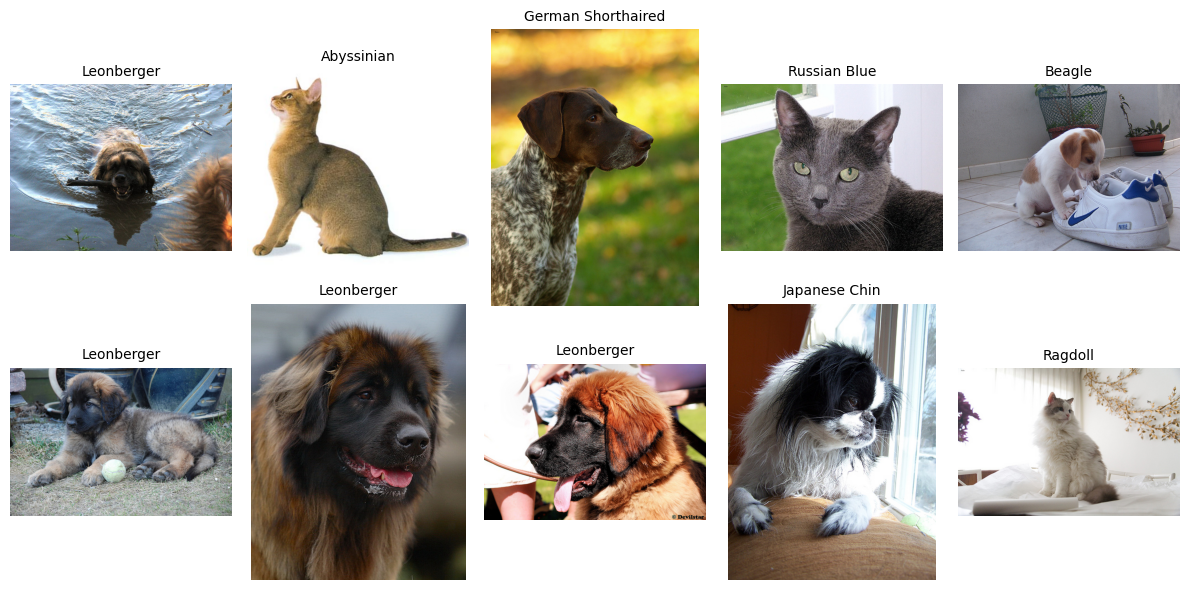

In [8]:
# Visualização de imagens
print("Imagens dos dez primeiros dados de treino:")

fig = plt.figure(figsize=(12, 6))
for i in range(10):
    ax = fig.add_subplot(2, 5, i+1)
    image, label = train_dataset[i]
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(breed_names[label], fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [11]:
# Distribuição das classes em treino
labels = np.array([train_dataset[i][1] for i in range(len(train_dataset))])
unique, counts = np.unique(labels, return_counts=True)

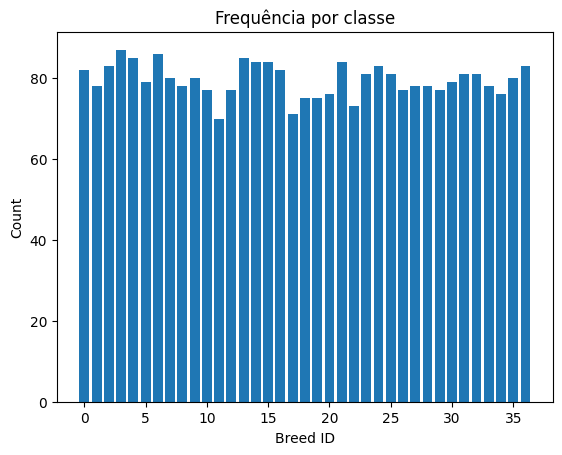

In [12]:
plt.bar(unique, counts)
plt.xlabel("Breed ID")
plt.ylabel("Count")
plt.title("Frequência por classe")
plt.show()

Como as imagens têm dimensões diferentes, precisamos redimensioná-las para um padrão comum.

In [13]:
transform_resize = transforms.Compose([
                    transforms.Resize((224, 224)),
                    transforms.ToTensor()
                ])

trainval_dataset = OxfordIIITPet(root="./data", split="trainval", transform=transform_resize, download=True)
test_dataset = OxfordIIITPet(root="./data", split="test", transform=transform_resize, download=True)

val_size = int(0.2 * len(trainval_dataset))
train_size = len(trainval_dataset) - val_size

train_dataset, val_dataset = random_split(trainval_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### Resposta 2.4–2.5

Com base nas visualizações e na distribuição por classe, descreva brevemente o que você observou.


Identifiquei que há 37 classes distintas nesse dataset. Explorando a pasta annotations dos dados, identifiquei que essas classes correspondem a raças de gato e cachorro.

Os labels são numéricos e as imagens do dataset têm dimensões espaciais diferentes (tanto em altura quanto em largura). Todas elas possuem 3 features (RGB).

Como as redes esperam dados de dimensões fixas, eu redimensionei as imagens para todas ficarem no padrão 224x224 e redefini os DataLoaders com essa alteração.

Quanto à distribuição dos dados por classe, o dataset parece estar bem balanceado. No histograma de frequência por classe no dataset de treino, é possível notar que cada classe possui cerca de 80 observações.

## 3. Construa uma FNN simples

Agora construa um primeiro modelo totalmente conectado (**FNN**).

**Tarefas**
1. Defina uma arquitetura simples em PyTorch.
2. Sua FNN deve receber a imagem achatada.
3. Escolha dimensões ocultas razoáveis.
4. Informe o número de parâmetros do modelo.

**Observação.**
Este modelo serve como baseline simples. Não é esperado que funcione bem.


In [14]:
# TODO:
# - definir uma classe FNN(nn.Module)
# - achatar a entrada
# - retornar logits para o número de classes
# - criar uma instância do modelo

# Dica:
# class SimpleFNN(nn.Module):
#     ...

# Escreva seu código aqui
class SimpleFNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        layer_sizes = [3*224*224, 512, 256, 128, 37]
        layers = []
        
        for i in range(len(layer_sizes) - 1):
            layers.append(
                nn.Linear(layer_sizes[i], layer_sizes[i+1])
            )
            if i != len(layer_sizes) - 2:
                layers.append(nn.ReLU())
                
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        out = x.reshape(x.size(0), -1)
        out = self.network(out)
            
        return out

TODO: NÚMERO DE PARÂMETROS DO MODELO

## 4. Crie funções de treino e avaliação

Implemente funções reutilizáveis para os próximos experimentos.

**Tarefas**
1. Crie uma função `train_one_epoch`.
2. Crie uma função `evaluate`.
3. Crie uma função `fit` que registre métricas por época.
4. Sua avaliação deve retornar pelo menos:
   - loss média
   - acurácia

**Importante.**
Essas funções serão reutilizadas em várias partes do trabalho.


### Resposta 4.1

In [15]:
# TODO:
# - implementar train_one_epoch
# - implementar evaluate
# - implementar fit
# - opcional: salvar histórico em dicionário

# Assinaturas sugeridas:
# def train_one_epoch(model, loader, optimizer, criterion, device):
#     ...
#
# @torch.no_grad()
# def evaluate(model, loader, criterion, device):
#     ...
#
# def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, scheduler=None):
#     ...

# Escreva seu código aqui

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

### Resposta 4.2

In [16]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        running_loss += loss.item()

        total += labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        
    loss = running_loss / len(loader)
    accuracy = 100 * correct / total

    return loss, accuracy

### Resposta 4.3

In [17]:
def plot_evaluation(epochs, model_hist):
    train_loss_hist, train_accuracy_hist, val_loss_hist, val_accuracy_hist = model_hist

    epoch_range = range(1, epochs + 1)
    
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    ax1.plot(epoch_range, train_loss_hist, label="Train Loss", color="blue", lw=2)
    ax1.plot(epoch_range, val_loss_hist, label="Validation Loss", color="orange", lw=2)
    ax1.set_title("Loss vs. Epochs", fontsize=14, pad=15)
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Loss", fontsize=12)
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.6)

    ax2.plot(epoch_range, train_accuracy_hist, label="Train Acc", color="blue", lw=2)
    ax2.plot(epoch_range, val_accuracy_hist, label="Validation Acc", color="orange", lw=2)
    ax2.set_title("Accuracy vs. Epochs", fontsize=14, pad=15)
    ax2.set_xlabel("Epoch", fontsize=12)
    ax2.set_ylabel("Accuracy (%)", fontsize=12)
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()
    
def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, scheduler=None):
    train_loss_hist = []
    val_loss_hist = []
    train_accuracy_hist = []
    val_accuracy_hist = []
    
    for i in range(epochs):
        train_one_epoch(model, train_loader, optimizer, criterion, device)
        
        train_loss, train_accuracy = evaluate(model, train_loader, criterion, device)
        train_loss_hist.append(train_loss)
        train_accuracy_hist.append(train_accuracy)

        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)
        val_loss_hist.append(val_loss)
        val_accuracy_hist.append(val_accuracy)
        
        print(f"{i+1}/{epochs} --- loss: {train_loss} | acc treino: {train_accuracy} | acc val: {val_accuracy}")
    
    return (train_loss_hist, train_accuracy_hist, val_loss_hist, val_accuracy_hist)

## 5. Treine e avalie a FNN

Use as funções anteriores para treinar sua FNN.

**Tarefas**
1. Escolha uma loss apropriada.
2. Escolha um otimizador.
3. Treine por algumas épocas.
4. Mostre curvas de treino/validação.
5. Reporte as métricas finais em validação.
6. Faça um comentário curto sobre o desempenho da FNN.

**Sugestão.**
Registre as escolhas de hiperparâmetros em uma célula ou tabela.


In [18]:
# TODO:
# - definir criterion e optimizer
# - treinar a FNN
# - guardar histórico
# - plotar curvas
# - reportar métricas finais

# Escreva seu código aqui

simpleFNN = SimpleFNN().to(device)

### Resposta 5.1: Escolha da loss

In [19]:
cross_entropy = nn.CrossEntropyLoss()

### Resposta 5.2: Escolha do otimizador

In [20]:
optim_simpleFNN = optim.Adam(simpleFNN.parameters())

### Resposta 5.3: Treino da FNN simples

In [21]:
epochs = 50
simpleFNN_hist = fit(simpleFNN, train_loader, val_loader, optim_simpleFNN, cross_entropy, device, epochs)

1/50 --- loss: 3.606833172881085 | acc treino: 2.5815217391304346 | acc val: 3.8043478260869565
2/50 --- loss: 3.611838003863459 | acc treino: 2.8872282608695654 | acc val: 2.4456521739130435
3/50 --- loss: 3.6093063354492188 | acc treino: 3.6684782608695654 | acc val: 3.260869565217391
4/50 --- loss: 3.6091160307759824 | acc treino: 3.6345108695652173 | acc val: 2.989130434782609
5/50 --- loss: 3.6081972381343013 | acc treino: 3.566576086956522 | acc val: 3.125
6/50 --- loss: 3.6061306103416113 | acc treino: 2.751358695652174 | acc val: 2.4456521739130435
7/50 --- loss: 3.5840227811232857 | acc treino: 3.974184782608696 | acc val: 4.211956521739131
8/50 --- loss: 3.563136012657829 | acc treino: 4.857336956521739 | acc val: 3.9402173913043477
9/50 --- loss: 3.518570117328478 | acc treino: 5.604619565217392 | acc val: 5.434782608695652
10/50 --- loss: 3.482064205667247 | acc treino: 5.740489130434782 | acc val: 4.891304347826087
11/50 --- loss: 3.4495132228602534 | acc treino: 5.6725543

In [28]:
def salvar_checkpoint(model, optimizer, history, epoch, filename="checkpoint.pth"):
    history_dict = {
        'train_loss': history[0],
        'train_acc': history[1],
        'val_loss': history[2],
        'val_acc': history[3]
    }
    
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history_dict
    }
    
    torch.save(checkpoint, filename)

In [29]:
salvar_checkpoint(simpleFNN, optim_simpleFNN, simpleFNN_hist, epochs, "simpleFNN.pth")

### Resposta 5.4: Curvas de treino/validação

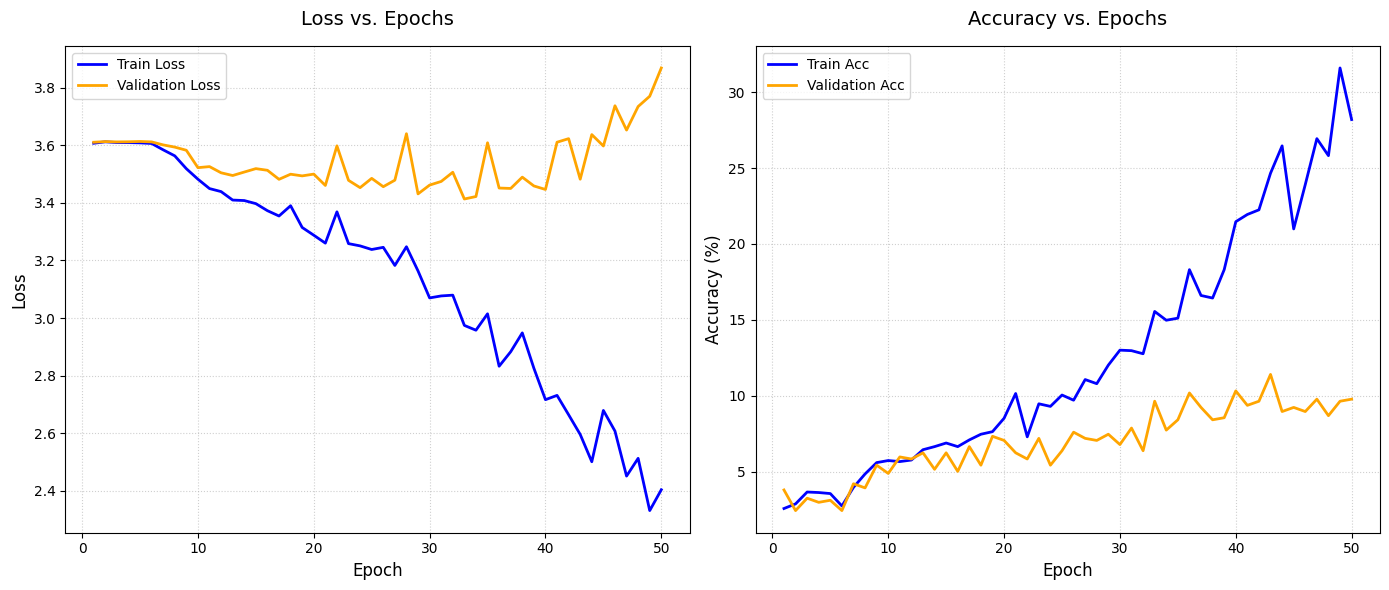

In [22]:
plot_evaluation(epochs, simpleFNN_hist)

### Resposta 5.5: Métricas finais em validação

In [23]:
val_loss, val_accuracy = evaluate(simpleFNN, val_loader, cross_entropy, device)
print(f"Validation loss: {val_loss:.4f} | Validation accuracy: {val_accuracy:.4f}")

Validation loss: 3.8718 | Validation accuracy: 9.7826


### Resposta 5.6: Comentando o desempenho da FNN

Comente brevemente o desempenho da FNN. Ela parece adequada para esse problema? Por quê?


## 6. Construa uma CNN simples e compare com a FNN

Agora implemente uma CNN simples.

**Tarefas**
1. Defina uma CNN com algumas camadas convolucionais.
2. Treine e avalie a CNN usando o mesmo protocolo da FNN.
3. Compare FNN e CNN em termos de:
   - acurácia;
   - comportamento das curvas;
   - número de parâmetros.

**Observação.**
A comparação deve ser baseada nos seus resultados.


### Resposta 6.1: Definição da arquitetura da CNN simples

In [106]:
# TODO:
# - definir uma CNN simples
# - treinar
# - avaliar
# - comparar com a FNN

# Dica:
# class SimpleCNN(nn.Module):
#     ...

# Escreva seu código aqui

class SimpleCNN(nn.Module):
    def __init__(self, dropout=False):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(
            nn.Linear(4608, 512),
            nn.ReLU(),

            nn.Dropout(p=0.5) if dropout else nn.Identity(512),

            nn.Linear(512, 37)
        )
    
    def forward(self, x):
        out = self.conv(x)
        out = self.flatten(out)
        out = self.fc(out)
        
        return out


### Resposta 6.2: Treino da CNN simples

In [25]:
simpleCNN = SimpleCNN().to(device)
optim_simpleCNN = optim.Adam(simpleCNN.parameters())

In [31]:
epochs = 50

simpleCNN_hist = fit(simpleCNN, train_loader, val_loader, optim_simpleCNN, cross_entropy, device, epochs)

1/50 --- loss: 3.3085084272467573 | acc treino: 9.273097826086957 | acc val: 8.016304347826088
2/50 --- loss: 3.2406145334243774 | acc treino: 11.650815217391305 | acc val: 9.51086956521739
3/50 --- loss: 3.136552624080492 | acc treino: 13.722826086956522 | acc val: 9.375
4/50 --- loss: 3.0155752067980557 | acc treino: 14.741847826086957 | acc val: 8.152173913043478
5/50 --- loss: 2.8743203722912334 | acc treino: 19.599184782608695 | acc val: 10.054347826086957
6/50 --- loss: 2.7392611451770947 | acc treino: 22.995923913043477 | acc val: 11.41304347826087
7/50 --- loss: 2.5464202217433765 | acc treino: 27.445652173913043 | acc val: 11.684782608695652
8/50 --- loss: 2.3318026065826416 | acc treino: 32.33695652173913 | acc val: 11.684782608695652
9/50 --- loss: 2.036047899204752 | acc treino: 41.50815217391305 | acc val: 12.771739130434783
10/50 --- loss: 1.7235371003980222 | acc treino: 50.577445652173914 | acc val: 11.277173913043478
11/50 --- loss: 1.2211333642835203 | acc treino: 63.

In [32]:
salvar_checkpoint(simpleCNN, optim_simpleCNN, simpleCNN_hist, epochs, "simpleCNN.pth")

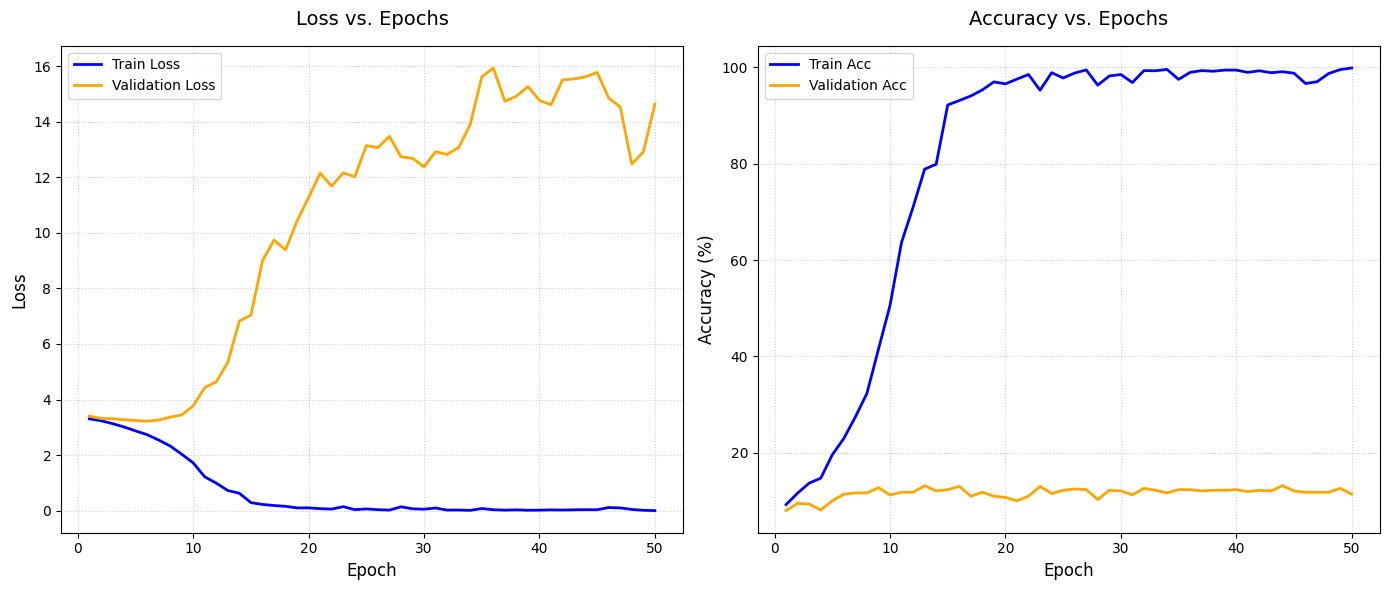

In [33]:
plot_evaluation(epochs, simpleCNN_hist)

In [34]:
val_loss, val_accuracy = evaluate(simpleCNN, val_loader, cross_entropy, device)
print(f"Validation loss: {val_loss:.4f} | Validation accuracy: {val_accuracy:.4f}")

Validation loss: 14.6280 | Validation accuracy: 11.4130


### Resposta 6.3: Comparação entre FNN e CNN simples

Compare FNN e CNN de forma objetiva. O que mudou? O resultado era esperado?


## 7. Faça pelo menos 3 modificações no treinamento

A partir da sua CNN simples, escolha **pelo menos 3** modificações da lista abaixo:

- Dara Augmentation;
- outro otimizador;
- learning rate scheduler;
- batch normalization;
- dropout;
- CNN mais profunda;
- weight decay regularizer.

**Tarefas**
1. Escolha no mínimo 3 modificações.
2. Execute experimentos controlados.
3. Organize os resultados em uma tabela.
4. Indique claramente qual configuração foi a melhor.

**Importante.**
Tente mudar uma coisa por vez sempre que possível.


### Resposta 7.1: Adição de modificação à CNN simples

In [35]:
# TODO:
# - definir ao menos 3 experimentos
# - treinar cada configuração
# - registrar resultados em uma tabela final


TODO: REMOVER

ideia de desenvolvimento:

antes de tudo: alterar a arquitetura da CNN simples para ficar mais parecida com a da VGG, para que o salto no passo 5 (descrito a seguir) não seja muito grande

1) adição de batch normalization para melhorar a questão do overfitting e a estabilidade do treinamento
2) dropout para diminuir overfitting
3) data augmentation para lidar com o tamanho limitado do dataset de treino e também com o overfitting
4) overfiting ainda não melhorou: usar global average pooling
5) aumentar a profundidade da rede com global average pooling

#### Batch Normalization

In [36]:
class ModifiedCNN(nn.Module):
    def __init__(self, dropout=False):
        super().__init__()

        self.conv = nn.Sequential(
            nn.BatchNorm2d(3),

            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(
            nn.Linear(4608, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Dropout(p=0.5) if dropout else nn.Identity(512),
            nn.Linear(512, 37)
        )
    
    def forward(self, x):
        out = self.conv(x)
        out = self.flatten(out)
        out = self.fc(out)
        
        return out

In [37]:
modifiedCNN1 = ModifiedCNN().to(device)
optim_modifiedCNN1 = optim.Adam(modifiedCNN1.parameters())

In [38]:
epochs = 50

modifiedCNN1_hist = fit(modifiedCNN1, train_loader, val_loader, optim_modifiedCNN1, cross_entropy, device, epochs)

1/50 --- loss: 2.9943206621252973 | acc treino: 15.48913043478261 | acc val: 11.548913043478262
2/50 --- loss: 2.680481547894685 | acc treino: 24.35461956521739 | acc val: 17.66304347826087
3/50 --- loss: 2.311585219010063 | acc treino: 33.59375 | acc val: 22.418478260869566
4/50 --- loss: 1.5055646222570669 | acc treino: 58.86548913043478 | acc val: 27.309782608695652
5/50 --- loss: 1.1129547940648121 | acc treino: 68.24048913043478 | acc val: 27.03804347826087
6/50 --- loss: 0.71569257715474 | acc treino: 83.05027173913044 | acc val: 25.815217391304348
7/50 --- loss: 0.20775874347790427 | acc treino: 97.89402173913044 | acc val: 31.657608695652176
8/50 --- loss: 0.06890079468164755 | acc treino: 99.96603260869566 | acc val: 35.733695652173914
9/50 --- loss: 0.014797495678067207 | acc treino: 100.0 | acc val: 36.82065217391305
10/50 --- loss: 0.007241984697706674 | acc treino: 100.0 | acc val: 39.53804347826087
11/50 --- loss: 0.004981585049434849 | acc treino: 100.0 | acc val: 39.130

In [39]:
salvar_checkpoint(modifiedCNN1, optim_modifiedCNN1, modifiedCNN1_hist, epochs, "modifiedCNN1.pth")

In [40]:
torch.save(modifiedCNN1.state_dict(), 'modifiedCNN1.pth')

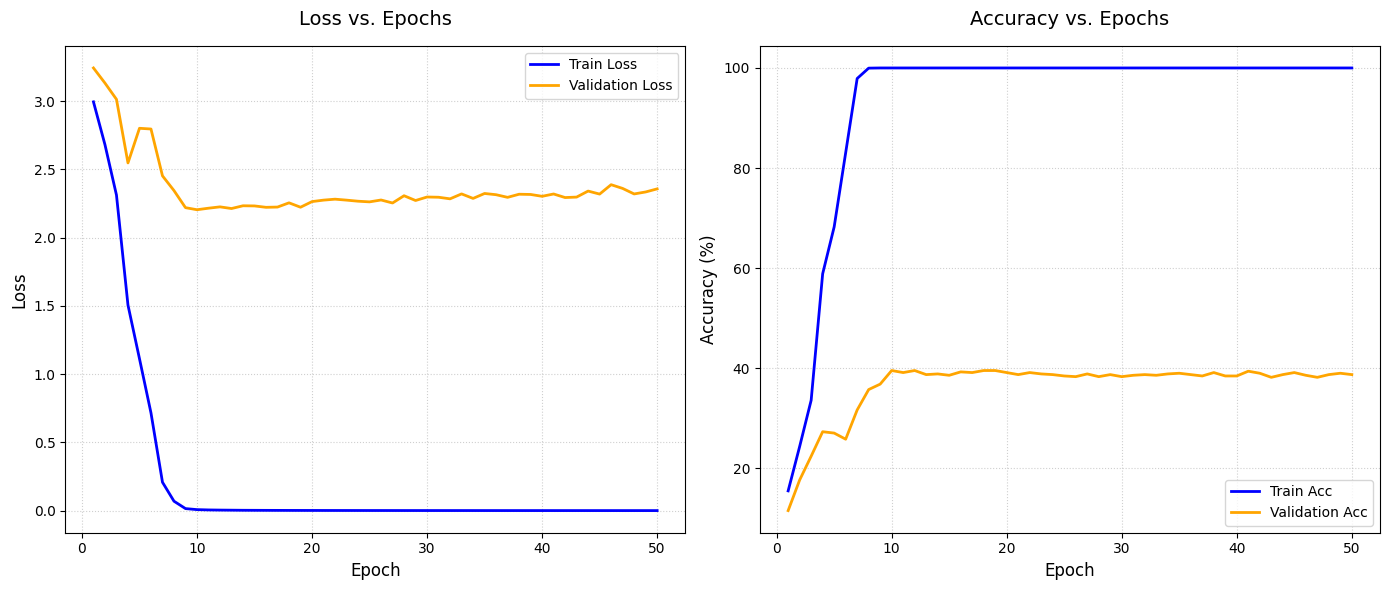

In [41]:
plot_evaluation(epochs, modifiedCNN1_hist)

#### Dropout

In [107]:
simpleCNNdrop = SimpleCNN(dropout=True).to(device)
optim_simpleCNNdrop = optim.Adam(simpleCNNdrop.parameters())

In [108]:
epochs = 30
simpleCNNdrop_hist = fit(simpleCNNdrop, train_loader, val_loader, optim_simpleCNNdrop, cross_entropy, device, epochs)

1/30 --- loss: 3.6106864939565244 | acc treino: 2.785326086956522 | acc val: 2.4456521739130435
2/30 --- loss: 3.5895702061445816 | acc treino: 2.9551630434782608 | acc val: 2.4456521739130435
3/30 --- loss: 3.4683044371397598 | acc treino: 5.978260869565218 | acc val: 6.25
4/30 --- loss: 3.3622956483260444 | acc treino: 7.948369565217392 | acc val: 6.385869565217392
5/30 --- loss: 3.299450236818065 | acc treino: 10.360054347826088 | acc val: 7.744565217391305
6/30 --- loss: 3.2254562533420064 | acc treino: 11.820652173913043 | acc val: 7.065217391304348
7/30 --- loss: 3.1365782851758213 | acc treino: 13.247282608695652 | acc val: 9.646739130434783
8/30 --- loss: 3.0509928827700405 | acc treino: 15.48913043478261 | acc val: 8.28804347826087
9/30 --- loss: 2.947859712268995 | acc treino: 19.123641304347824 | acc val: 10.326086956521738
10/30 --- loss: 2.78072974992835 | acc treino: 22.18070652173913 | acc val: 11.141304347826088
11/30 --- loss: 2.674019948295925 | acc treino: 24.7282608

In [118]:
salvar_checkpoint(simpleCNNdrop, optim_simpleCNNdrop, simpleCNNdrop_hist, epochs, "simpleCNNdrop.pth")

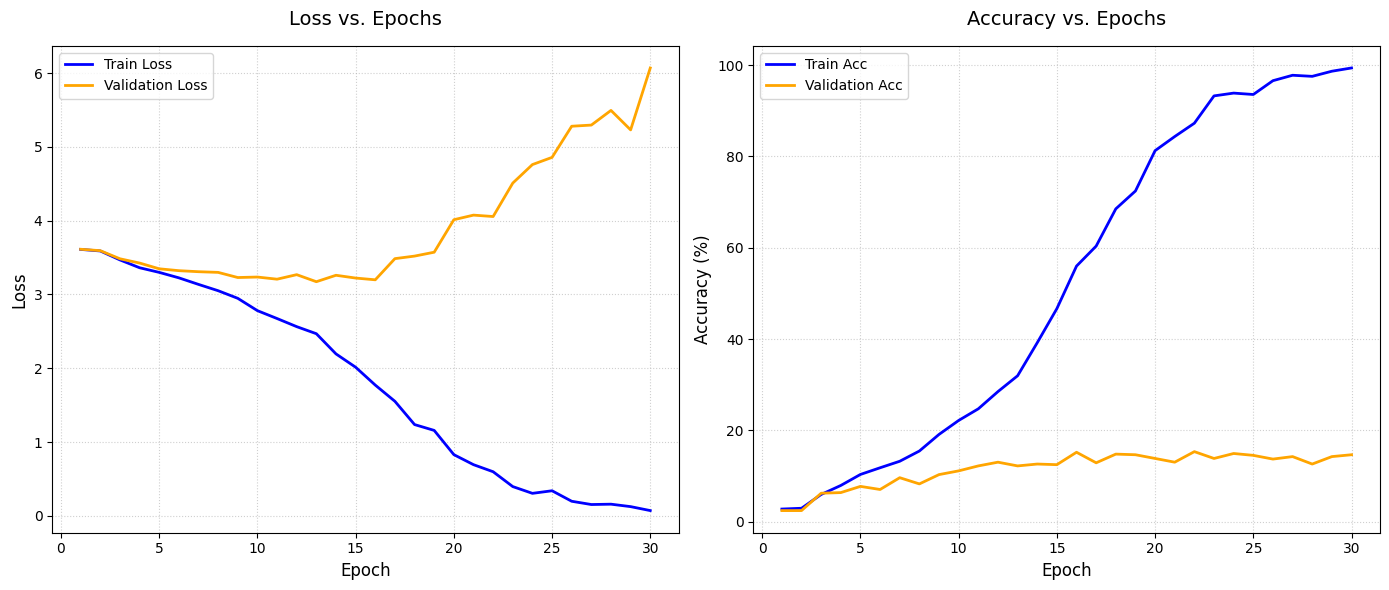

In [111]:
plot_evaluation(epochs, simpleCNNdrop_hist)

#### Data Augmentation

In [126]:
class ApplyImageTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        image, label = self.subset[index]
        image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.subset) 

In [127]:
img_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(size=224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2)
])

augmented_train_dataset = ApplyImageTransform(train_dataset, transform=img_transforms)
augmented_train_loader = DataLoader(dataset=augmented_train_dataset, batch_size=batch_size, shuffle=True)

In [130]:
simpleCNNaug = SimpleCNN().to(device)
optim_simpleCNNaug = optim.Adam(simpleCNNaug.parameters())

In [131]:
epochs = 50
simpleCNNaug_hist = fit(simpleCNNaug, augmented_train_loader, val_loader, optim_simpleCNNaug, cross_entropy, device, epochs)

1/50 --- loss: 3.6108303277388862 | acc treino: 2.989130434782609 | acc val: 1.4945652173913044
2/50 --- loss: 3.610523094301638 | acc treino: 2.989130434782609 | acc val: 1.4945652173913044
3/50 --- loss: 3.6102829134982564 | acc treino: 2.989130434782609 | acc val: 1.4945652173913044
4/50 --- loss: 3.6100429970285166 | acc treino: 2.989130434782609 | acc val: 1.4945652173913044
5/50 --- loss: 3.609849582547727 | acc treino: 2.989130434782609 | acc val: 1.4945652173913044
6/50 --- loss: 3.6097395160923833 | acc treino: 2.989130434782609 | acc val: 1.4945652173913044
7/50 --- loss: 3.6096117030019346 | acc treino: 3.0230978260869565 | acc val: 1.4945652173913044
8/50 --- loss: 3.609623509904613 | acc treino: 3.0230978260869565 | acc val: 1.4945652173913044
9/50 --- loss: 3.60951376479605 | acc treino: 2.989130434782609 | acc val: 1.4945652173913044


KeyboardInterrupt: 

In [ ]:
salvar_checkpoint(simpleCNNaug, optim_simpleCNNaug, simpleCNNaug_hist, epochs, "simpleCNNaug.pth")

In [ ]:
plot_evaluation(epochs, simpleCNNaug_hist)

#### Batch Normalization + Data Augmentation

In [120]:
modifiedCNNaug = ModifiedCNN().to(device)
optim_modifiedCNNaug = optim.Adam(modifiedCNNaug.parameters())

In [123]:
epochs = 50
modifiedCNNaug_hist = fit(modifiedCNNaug, augmented_train_loader, val_loader, optim_modifiedCNNaug, cross_entropy, device, epochs)

1/50 --- loss: 3.137524050215016 | acc treino: 13.824728260869565 | acc val: 12.228260869565217
2/50 --- loss: 2.94539531417515 | acc treino: 18.851902173913043 | acc val: 18.342391304347824
3/50 --- loss: 2.8556129880573438 | acc treino: 20.17663043478261 | acc val: 19.83695652173913
4/50 --- loss: 3.0200123942416646 | acc treino: 21.773097826086957 | acc val: 19.429347826086957
5/50 --- loss: 2.8105055145595386 | acc treino: 22.112771739130434 | acc val: 18.88586956521739
6/50 --- loss: 2.315286996571914 | acc treino: 33.15217391304348 | acc val: 27.98913043478261
7/50 --- loss: 2.4834639870602153 | acc treino: 29.99320652173913 | acc val: 25.0
8/50 --- loss: 2.297866290030272 | acc treino: 33.22010869565217 | acc val: 28.940217391304348
9/50 --- loss: 1.7337632801221765 | acc treino: 49.45652173913044 | acc val: 36.005434782608695
10/50 --- loss: 2.194408180920974 | acc treino: 37.36413043478261 | acc val: 26.358695652173914
11/50 --- loss: 1.8487603586653005 | acc treino: 44.259510

In [124]:
salvar_checkpoint(modifiedCNNaug, optim_modifiedCNNaug, modifiedCNNaug_hist, epochs, "modifiedCNNaug.pth")

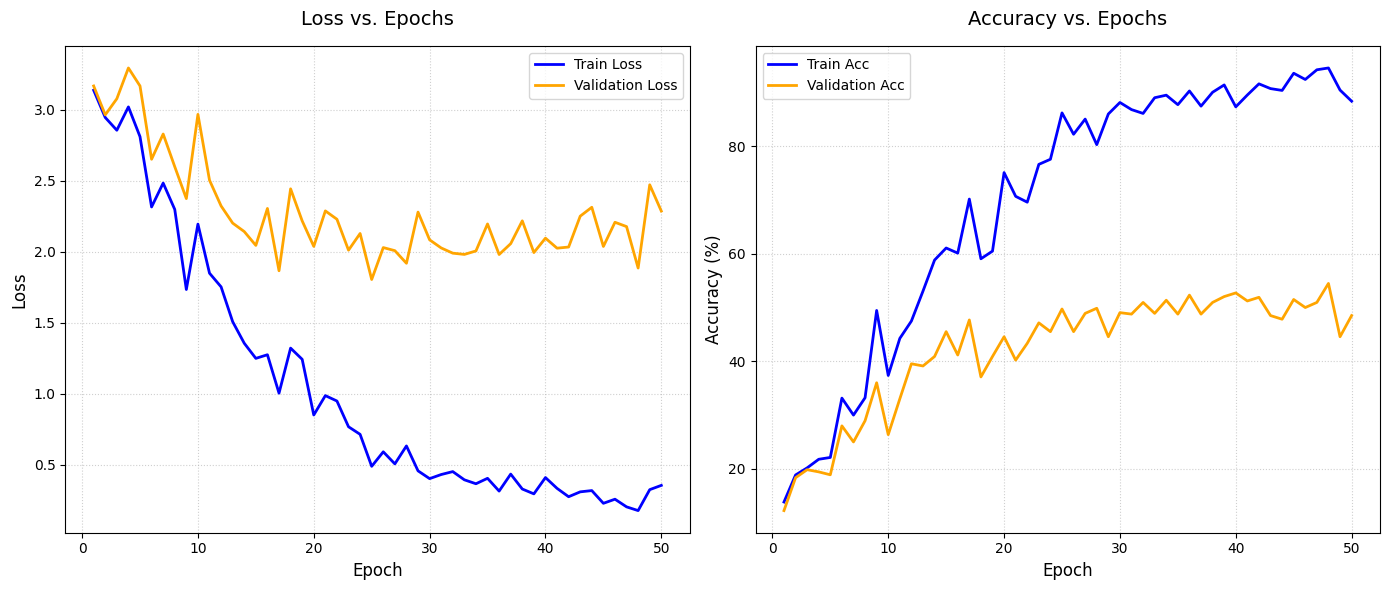

In [125]:
plot_evaluation(epochs, modifiedCNNaug_hist)

#### Batch Normalization + Dropout

TODO: testei mas ficou muito parecido com só batch normalization

#### Rede Mais Profunda + Batch Normalization

In [ ]:
class Deep_CNN(nn.Module):
    def __init__(self, dropout=False):
        super().__init__()

        self.conv = nn.Sequential(
            nn.BatchNorm2d(3),

            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.AdaptiveAvgPool2d((1,1)),
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=0.5) if dropout else nn.Identity(512),

            nn.Linear(512, 37),
        )
    
    def forward(self, x):
        out = self.conv(x)
        out = self.flatten(out)
        out = self.fc(out)
        
        return out

In [ ]:
deepCNN = Deep_CNN(dropout=True).to(device)
optim_deepCNN = optim.Adam(deepCNN.parameters(), lr=1e-4)

In [ ]:
epochs = 200

deepCNN_hist = fit(deepCNN, train_loader, val_loader, optim_deepCNN, cross_entropy, device, epochs)

1/200 --- loss: 3.558154230532439 | acc treino: 5.706521739130435 | acc val: 5.434782608695652
2/200 --- loss: 3.2679371108179507 | acc treino: 10.258152173913043 | acc val: 9.51086956521739
3/200 --- loss: 3.243910639182381 | acc treino: 13.485054347826088 | acc val: 12.36413043478261
4/200 --- loss: 3.211240022078804 | acc treino: 15.76086956521739 | acc val: 11.277173913043478
5/200 --- loss: 2.945081969966059 | acc treino: 18.44429347826087 | acc val: 18.070652173913043
6/200 --- loss: 2.526520278142846 | acc treino: 30.19701086956522 | acc val: 24.592391304347824
7/200 --- loss: 2.4881932994593745 | acc treino: 28.77038043478261 | acc val: 21.73913043478261
8/200 --- loss: 3.1995450880216514 | acc treino: 15.896739130434783 | acc val: 14.945652173913043
9/200 --- loss: 2.399556735287542 | acc treino: 30.876358695652176 | acc val: 24.592391304347824
10/200 --- loss: 2.4372222682704097 | acc treino: 29.279891304347824 | acc val: 21.195652173913043
11/200 --- loss: 2.4409547992374585

In [ ]:
salvar_checkpoint(deepCNN, optim_deepCNN, deepCNN_hist, epochs, "deepCNN.pth")

In [ ]:
plot_evaluation(epochs, deepCNN_hist)

#### Rede Mais Profunda + Batch Normalization + Data Augmentation

### Resposta 7.4

Liste as modificações escolhidas e justifique em 1–2 linhas por que você decidiu testá-las.


In [ ]:
deepCNNaug = Deep_CNN(dropout=True).to(device)
optim_deepCNNaug = optim.Adam(deepCNNaug.parameters(), lr=1e-4)

In [ ]:
epochs = 200

deepCNNaug_hist = fit(deepCNNaug, augmented_train_loader, val_loader, optim_deepCNNaug, cross_entropy, device, epochs)

1/200 --- loss: 1.8952444714048635 | acc treino: 56.35190217391305 | acc val: 54.07608695652174
2/200 --- loss: 1.2153106914914173 | acc treino: 66.03260869565217 | acc val: 54.755434782608695
3/200 --- loss: 1.556516293598258 | acc treino: 59.78260869565217 | acc val: 59.51086956521739
4/200 --- loss: 1.087533642416415 | acc treino: 68.24048913043478 | acc val: 60.05434782608695
5/200 --- loss: 1.2028807997703552 | acc treino: 66.50815217391305 | acc val: 55.29891304347826
6/200 --- loss: 0.878264482902444 | acc treino: 74.52445652173913 | acc val: 62.09239130434783
7/200 --- loss: 1.253523922484854 | acc treino: 63.55298913043478 | acc val: 60.05434782608695
8/200 --- loss: 0.7947072529274485 | acc treino: 77.03804347826087 | acc val: 59.91847826086956
9/200 --- loss: 0.8919796088467473 | acc treino: 73.94701086956522 | acc val: 61.95652173913044
10/200 --- loss: 0.7498520975527556 | acc treino: 77.5475543478261 | acc val: 65.76086956521739
11/200 --- loss: 0.9404211795848348 | acc t

KeyboardInterrupt: 

In [ ]:
salvar_checkpoint(deepCNNaug, optim_deepCNNaug, deepCNNaug_hist, epochs, "deepCNNaug.pth")

In [ ]:
plot_evaluation(epochs, deepCNNaug_hist)

NameError: name 'modifiedCNN7_hist' is not defined

## 8. Analise e discuta o efeito das mudanças

Com base nos experimentos da parte anterior:

**Tarefas**
1. Discuta quais mudanças ajudaram mais.
2. Discuta quais mudanças pouco ajudaram ou pioraram o resultado.
3. Comente possíveis razões para o comportamento observado.
4. Indique qual modelo/configuração você levará para a etapa final.

Use evidências das métricas e curvas.


### Resposta 8

Escreva sua análise aqui.


## 9. Treine usando uma ResNet pré-treinada

Agora use **transfer learning** com uma **ResNet pré-treinada**.

**Tarefas**
1. Carregue uma ResNet pré-treinada do `torchvision`.
2. Adapte a última camada para o número de classes.
3. Treine ao menos uma versão usando transfer learning.
4. Compare com sua melhor CNN da Parte 7.

**Sugestão.**
Você pode começar congelando a maior parte da rede e depois testar fine-tuning.


In [65]:
# TODO:
# - carregar uma ResNet pré-treinada
# - adaptar a camada final
# - treinar
# - avaliar e comparar

# Dica:
# from torchvision.models import resnet18, ResNet18_Weights

# Escreva seu código aqui

from torchvision import models

# Arquitetura de resnet com os pesos treinados para o ImageNet
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in resnet.parameters():
    param.requires_grad = False

num_ftrs = resnet.fc.in_features

resnet.fc = nn.Sequential(
    nn.Linear(num_ftrs, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    
    nn.Dropout(0.5),
    nn.Linear(128, 37)
)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/al.taina.drumond/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 77.3MB/s]


In [ ]:
epochs = 30

resnet = resnet.to(device)
optim_resnet = optim.Adam(resnet.fc.parameters())

resnet_hist = fit(resnet, augmented_train_loader, val_loader, optim_resnet, cross_entropy, device, epochs)

1/200 --- loss: 1.5773470246273538 | acc treino: 84.51086956521739 | acc val: 82.8804347826087
2/200 --- loss: 0.9238395237404368 | acc treino: 91.3383152173913 | acc val: 88.31521739130434
3/200 --- loss: 0.6102802617394406 | acc treino: 93.44429347826087 | acc val: 88.9945652173913
4/200 --- loss: 0.43202048799265985 | acc treino: 94.70108695652173 | acc val: 89.40217391304348
5/200 --- loss: 0.32662107665901596 | acc treino: 96.22961956521739 | acc val: 90.625
6/200 --- loss: 0.24349434608998505 | acc treino: 97.18070652173913 | acc val: 91.30434782608695
7/200 --- loss: 0.19117096244640971 | acc treino: 97.96195652173913 | acc val: 90.21739130434783
8/200 --- loss: 0.15928913863456767 | acc treino: 98.70923913043478 | acc val: 89.80978260869566
9/200 --- loss: 0.1289594395329123 | acc treino: 98.74320652173913 | acc val: 91.57608695652173
10/200 --- loss: 0.1063428166443887 | acc treino: 98.98097826086956 | acc val: 90.21739130434783
11/200 --- loss: 0.09262056551549745 | acc trein

KeyboardInterrupt: 

In [ ]:
salvar_checkpoint(resnet, optim_resnet, resnet_hist, epochs, "resnet.pth")

### Resposta 9.4

Compare a ResNet com sua melhor CNN anterior. O ganho compensou?


## 10. Avaliações finais

Escolha seu melhor modelo final e faça uma avaliação mais detalhada.

**Tarefas**
1. Avalie no conjunto de teste.
2. Reporte:
   - loss;
   - acurácia;
   - matriz de confusão.
3. Mostre algumas imagens classificadas incorretamente.
4. Identifique pares de classes que geram mais confusão.
5. Discuta brevemente os principais erros do modelo.

**Observação.**
Use esta parte para mostrar que você inspecionou o comportamento do modelo além da acurácia final.


In [ ]:
# TODO:
# - avaliar no teste
# - calcular matriz de confusão
# - mostrar erros
# - discutir pares confusos

# Sugestão:
# use sklearn.metrics.confusion_matrix ou implementação própria

# Escreva seu código aqui


### Resposta 10.5

Discuta os erros mais importantes observados na avaliação final.


## 11. Bônus — Robustez

Faça um teste simples de robustez com o seu melhor modelo.

**Exemplos de variações possíveis**
- reduzir a resolução da imagem;
- adicionar ruído leve;
- mudar brilho/contraste;
- aplicar blur leve;
- testar imagens com crop diferente.

**Tarefas**
1. Escolha uma perturbação simples.
2. Compare o desempenho antes e depois.
3. Mostre alguns exemplos.
4. Comente o que isso sugere sobre a robustez do modelo.


In [ ]:
# TODO:
# - definir uma perturbação simples
# - reavaliar o melhor modelo
# - comparar métricas
# - mostrar exemplos

# Escreva seu código aqui

## Critérios de avaliação

A correção levará em conta:
- **implementação correta** dos componentes pedidos;
- **qualidade experimental** das comparações;
- **clareza da análise** dos resultados;
- **organização** do notebook;
- **coerência** entre conclusões e evidências.
